# Analyse causale — Team Visma | Lease a Bike

**Focus :** Comparaison de l'effet causal de **Jonas Vingegaard** vs **Wout Van Aert**

**Structure :**
1. Configuration & chargement
2. Statistiques descriptives équipe
3. Biais de sélection — Vingegaard vs Van Aert
4. DML — ATE pour tous les coureurs
5. Causal Forest — Hétérogénéité Vingegaard vs Van Aert
6. Comparaison des deux profils

## 0. Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from econml.dml import CausalForestDML
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.2f}'.format)

RIDER_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'
RACE_PATH = '/Users/arthurdeletang/Desktop/Stage M1/Code/race_data/race_features.csv'

# ── CONFIGURATION ─────────────────────────────────────────────────────────
EQUIPE  = 'Team Visma | Lease a Bike'
ANNEES  = [2024, 2025]   # plusieurs années pour avoir plus d'observations
COUREUR_1 = 'vingegaard_jonas.csv'
COUREUR_2 = 'van_aert_wout.csv'

print(f'Equipe  : {EQUIPE}')
print(f'Annees  : {ANNEES}')
print(f'Focus 1 : {COUREUR_1}')
print(f'Focus 2 : {COUREUR_2}')

/Users/arthurdeletang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Equipe  : Team Visma | Lease a Bike
Annees  : [2024, 2025]
Focus 1 : vingegaard_jonas.csv
Focus 2 : van_aert_wout.csv


## 1. Détection des coureurs & chargement

In [2]:
def find_team_riders(equipe, annees, rider_dir):
    riders = []
    for f in os.listdir(rider_dir):
        if not f.endswith('.csv'):
            continue
        try:
            df = pd.read_csv(os.path.join(rider_dir, f), usecols=['year', 'equipe'])
            if ((df['year'].isin(annees)) & (df['equipe'] == equipe)).any():
                riders.append(f)
        except:
            continue
    return sorted(riders)

def load_rider(filename, annees, equipe):
    df_rider = pd.read_csv(os.path.join(RIDER_DIR, filename))
    df_race  = pd.read_csv(RACE_PATH)
    df_rider = df_rider[df_rider['year'].isin(annees) & (df_rider['equipe'] == equipe)]
    if len(df_rider) == 0:
        return None
    df_rider['stage_num'] = pd.to_numeric(df_rider['etape'],    errors='coerce')
    df_rider['year']      = pd.to_numeric(df_rider['year'],     errors='coerce').astype('Int64')
    df_race['year']       = pd.to_numeric(df_race['year'],      errors='coerce').astype('Int64')
    df_race['stage_num']  = pd.to_numeric(df_race['stage_num'], errors='coerce')
    df_rider['rider']     = filename.replace('.csv', '')
    return df_rider.merge(
        df_race.drop(columns=['stage', 'classification', 'date'], errors='ignore'),
        on=['course', 'year', 'stage_num'], how='left'
    )

print('Recherche des coureurs...')
RIDERS = find_team_riders(EQUIPE, ANNEES, RIDER_DIR)
print(f'{len(RIDERS)} coureurs trouves :')
for r in RIDERS:
    print(f'  {r}')

Recherche des coureurs...
52 coureurs trouves :
  affini_edoardo.csv
  behrens_niklas.csv
  belletta_dario_igor.csv
  benoot_tiesj.csv
  bouwman_koen.csv
  brennan_matthew.csv
  campenaerts_victor.csv
  gesink_robert.csv
  gloag_thomas.csv
  graat_tijmen.csv
  hagenes_per_strand.csv
  huising_menno.csv
  høydahl_jonas_kind.csv
  jorgenson_matteo.csv
  kelderman_wilco.csv
  keppens_cedric.csv
  kings_ian.csv
  kooij_olav.csv
  kramer_jesse.csv
  kruijswijk_steven.csv
  kuss_sepp.csv
  laporte_christophe.csv
  lemmen_bart.csv
  lugthart_sjors.csv
  mattio_pietro.csv
  mclay_daniel.csv
  nordhagen_jørgen.csv
  nørtoft_morten_aalling.csv
  pattinson_tomos.csv
  rex_tim.csv
  schellekens_tom.csv
  simmons_colby.csv
  smith_william.csv
  smithson_jed.csv
  tratnik_jan.csv
  tulett_ben.csv
  uglehus_mikal_grimstad.csv
  uijtdebroeks_cian.csv
  vader_milan.csv
  valter_attila.csv
  van_aert_wout.csv
  van_baarle_dylan.csv
  van_bekkum_darren.csv
  van_belle_loe.csv
  van_der_sande_tosh.csv
  v

In [3]:
# Charger tous les coureurs
dfs = [load_rider(f, ANNEES, EQUIPE) for f in RIDERS]
df_team = pd.concat([d for d in dfs if d is not None], ignore_index=True)

print(f'Dataset {EQUIPE} {ANNEES} :')
print(f'  Coureurs        : {df_team["rider"].nunique()}')
print(f'  Lignes totales  : {len(df_team)}')
print(f'  Courses uniques : {df_team["course"].nunique()}')
print(f'  selected=1      : {(df_team["selected"]==1).sum()}')
print(f'  selected=0      : {(df_team["selected"]==0).sum()}')
print(f'  Match GPX       : {df_team["distance_gpx_km"].notna().sum()}/{len(df_team)} ({df_team["distance_gpx_km"].notna().mean()*100:.1f}%)')

Dataset Team Visma | Lease a Bike [2024, 2025] :
  Coureurs        : 52
  Lignes totales  : 19180
  Courses uniques : 99
  selected=1      : 3117
  selected=0      : 16063
  Match GPX       : 18466/19180 (96.3%)


## 2. Statistiques descriptives

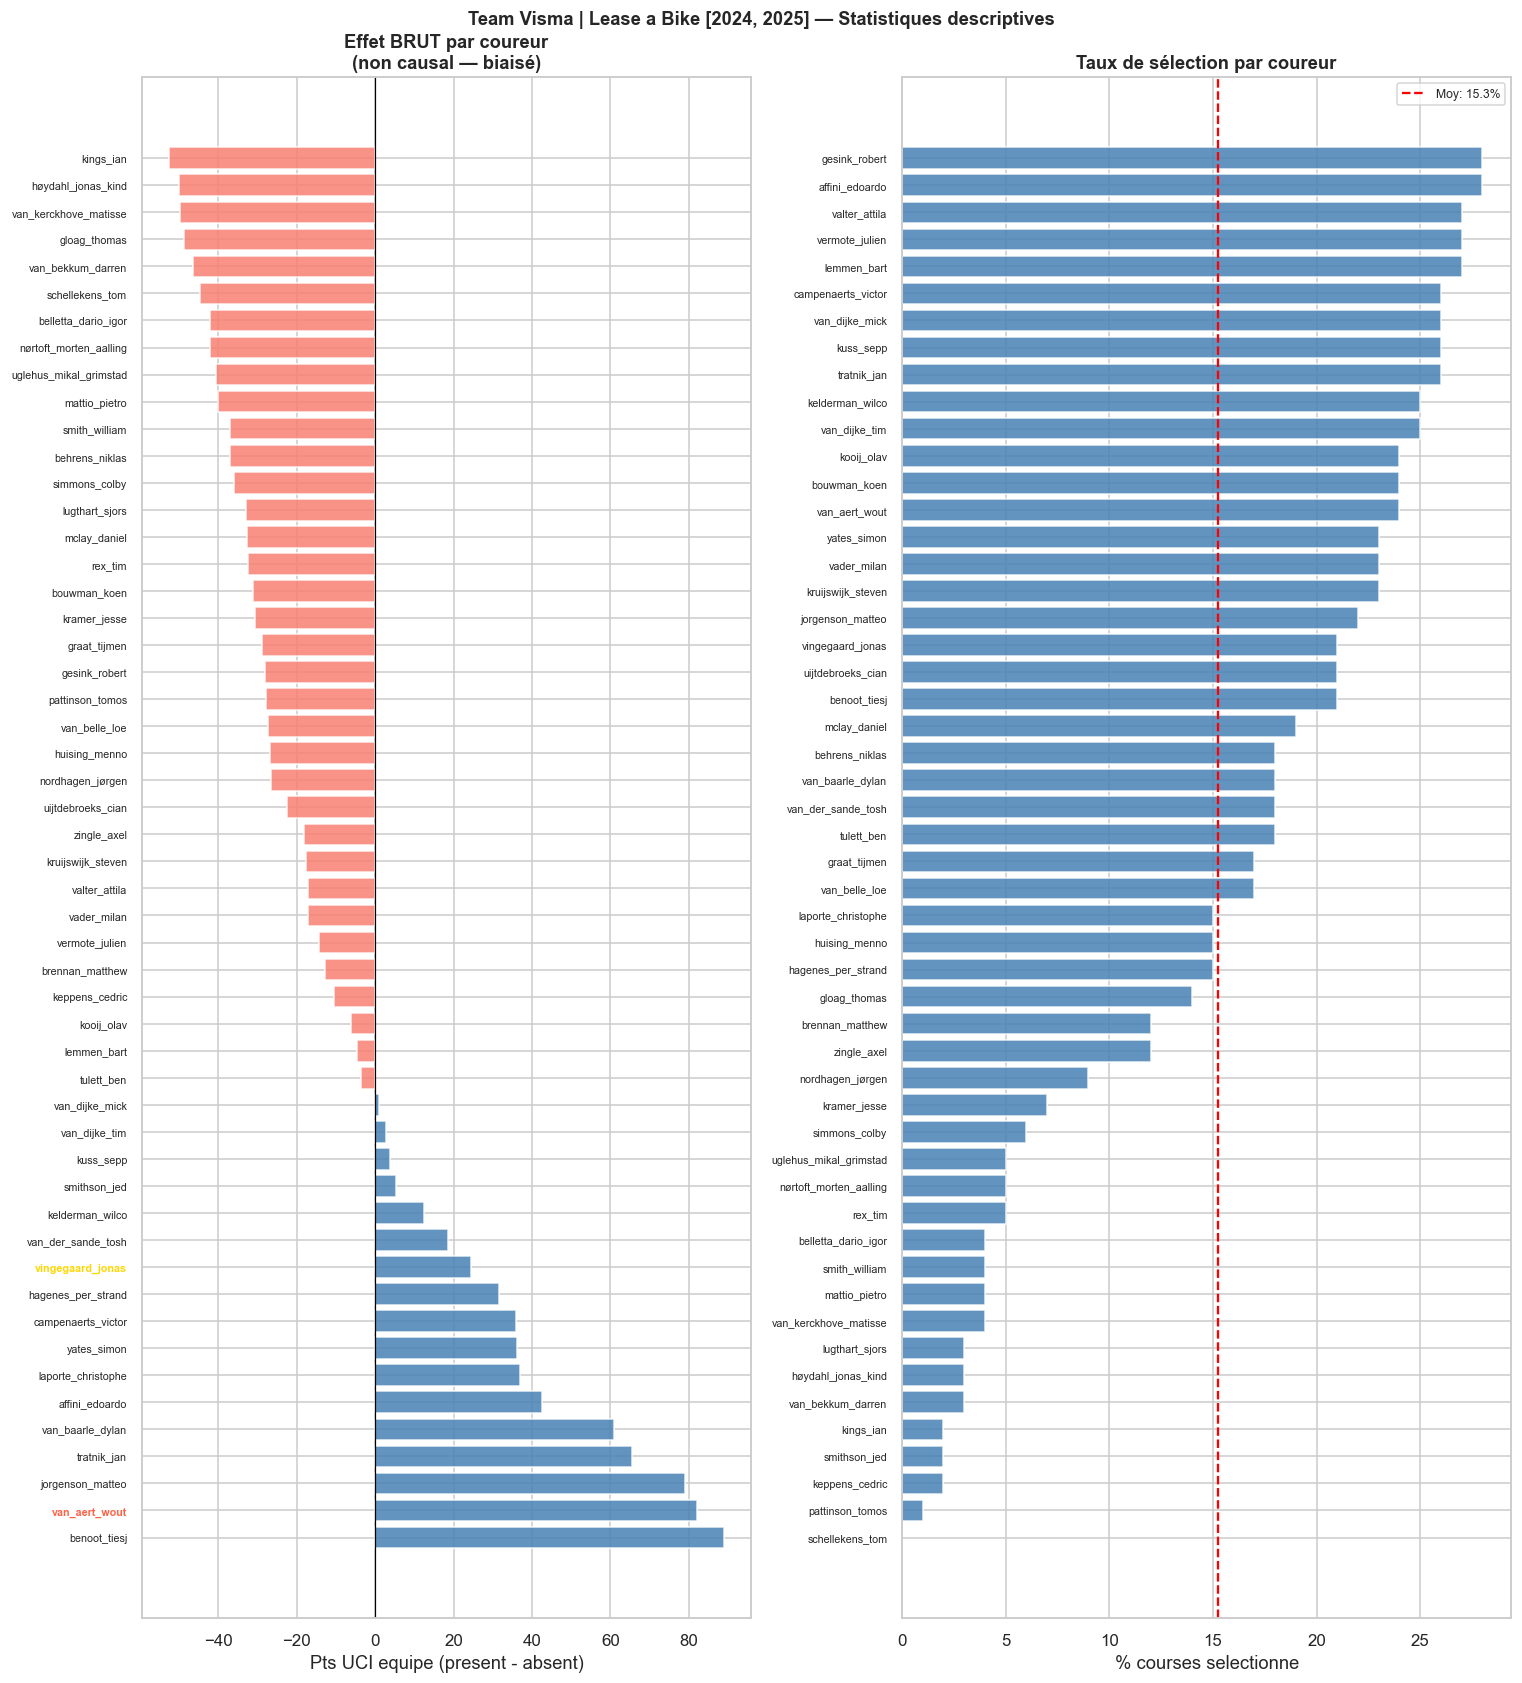

Stats completes :
                        n_obs  n_selected  taux_selection  pts_present  pts_absent  effet_brut
rider                                                                                         
benoot_tiesj              490         105            0.21       120.35       31.43       88.92
van_aert_wout             486         118            0.24       112.87       30.83       82.04
jorgenson_matteo          491         109            0.22       111.94       32.83       79.11
tratnik_jan               238          63            0.26        95.76       30.18       65.58
van_baarle_dylan          465          84            0.18       100.71       39.79       60.92
affini_edoardo            491         138            0.28        81.08       38.39       42.69
laporte_christophe        478          70            0.15        82.43       45.55       36.88
yates_simon               253          58            0.23        80.90       44.79       36.11
campenaerts_victor        245   

In [4]:
# Stats par coureur
stats = df_team.groupby('rider').agg(
    n_obs=('selected', 'count'),
    n_selected=('selected', 'sum'),
    taux_selection=('selected', 'mean'),
    pts_present=('pts_uci_equipe', lambda x: x[df_team.loc[x.index, 'selected']==1].mean()),
    pts_absent=('pts_uci_equipe',  lambda x: x[df_team.loc[x.index, 'selected']==0].mean()),
).round(2)
stats['effet_brut'] = (stats['pts_present'] - stats['pts_absent']).round(2)
stats = stats.sort_values('effet_brut', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(stats)*0.3)))

# Effet brut
colors_b = ['steelblue' if x > 0 else 'salmon' for x in stats['effet_brut']]
axes[0].barh(stats.index, stats['effet_brut'], color=colors_b, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pts UCI equipe (present - absent)')
axes[0].set_title('Effet BRUT par coureur\n(non causal — biaisé)', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=7)
# Mettre en evidence Ving et VdA
nom_ving = [r for r in stats.index if 'vingegaard' in r][0]
nom_vda  = [r for r in stats.index if 'aert' in r][0]
for nom, col in [(nom_ving, 'gold'), (nom_vda, 'tomato')]:
    if nom in stats.index:
        y = list(stats.index).index(nom)
        axes[0].get_yticklabels()[y].set_color(col)
        axes[0].get_yticklabels()[y].set_fontweight('bold')

# Taux de selection
stats_s = stats.sort_values('taux_selection', ascending=True)
axes[1].barh(stats_s.index, stats_s['taux_selection']*100, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(stats['taux_selection'].mean()*100, color='red', linestyle='--',
                label=f'Moy: {stats["taux_selection"].mean()*100:.1f}%')
axes[1].set_xlabel('% courses selectionne')
axes[1].set_title('Taux de sélection par coureur', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].legend(fontsize=8)

plt.suptitle(f'{EQUIPE} {ANNEES} — Statistiques descriptives', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Stats completes :')
print(stats[['n_obs', 'n_selected', 'taux_selection', 'pts_present', 'pts_absent', 'effet_brut']].to_string())

## 3. Biais de sélection — Vingegaard vs Van Aert

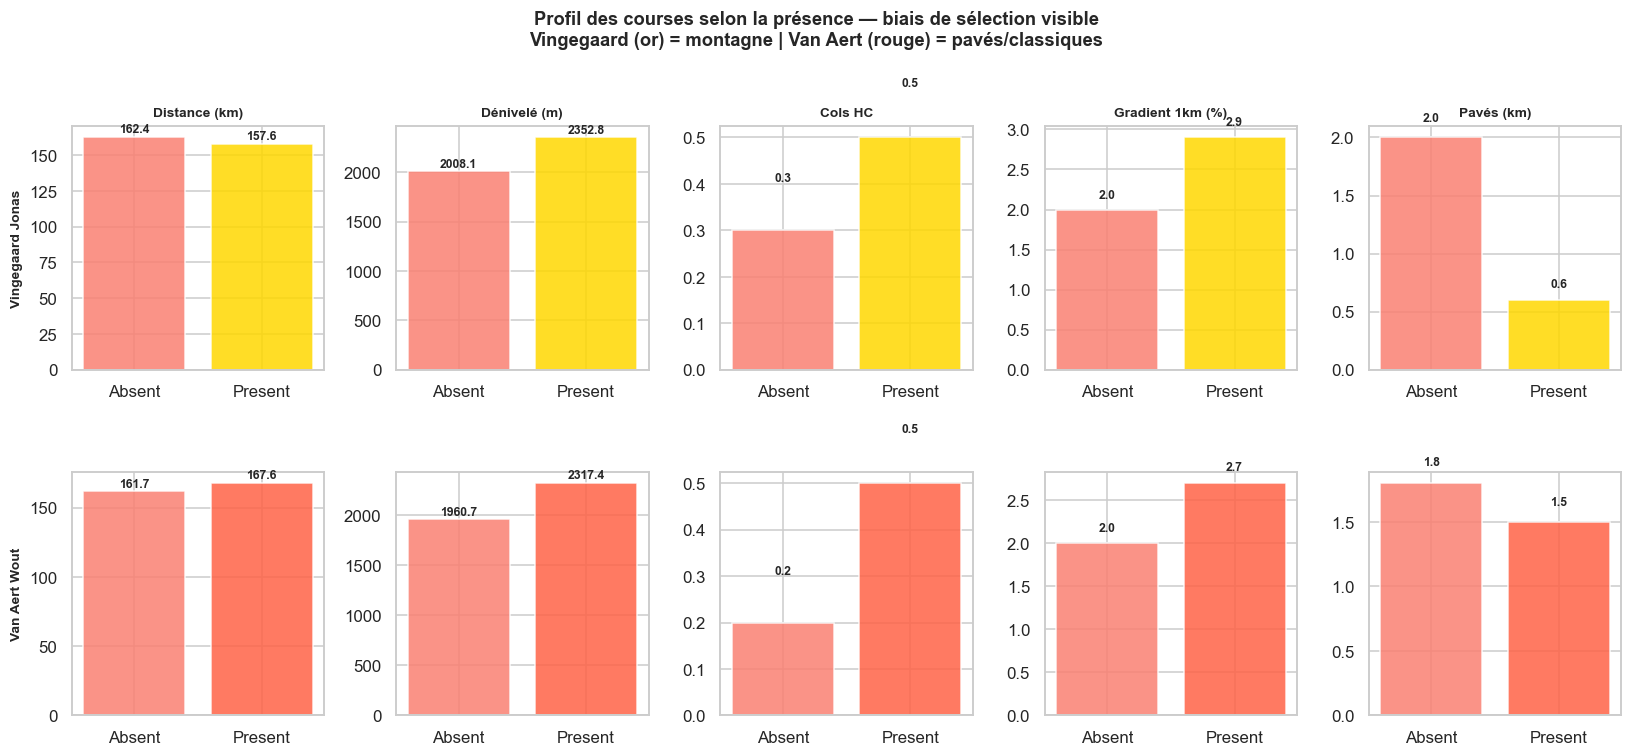

Vingegaard Jonas :
          distance_gpx_km  denivele_pos  n_cols_hc  gradient_last_1km  \
selected                                                                
Absent             162.40       2008.10       0.30               2.00   
Present            157.60       2352.80       0.50               2.90   

          cobblestones_km  
selected                   
Absent               2.00  
Present              0.60  

Van Aert Wout :
          distance_gpx_km  denivele_pos  n_cols_hc  gradient_last_1km  \
selected                                                                
Absent             161.70       1960.70       0.20               2.00   
Present            167.60       2317.40       0.50               2.70   

          cobblestones_km  
selected                   
Absent               1.80  
Present              1.50  



In [5]:
# Profil des courses selon la presence — comparaison Ving vs VdA
cols_profil = ['distance_gpx_km', 'denivele_pos', 'n_cols_hc',
               'gradient_last_1km', 'cobblestones_km']
cols_profil = [c for c in cols_profil if c in df_team.columns]
labels_fr   = ['Distance (km)', 'Dénivelé (m)', 'Cols HC', 'Gradient 1km (%)', 'Pavés (km)']

nom_ving = [r for r in df_team['rider'].unique() if 'vingegaard' in r][0]
nom_vda  = [r for r in df_team['rider'].unique() if 'aert' in r][0]
coureurs_focus = [nom_ving, nom_vda]
noms_affichage = ['Vingegaard Jonas', 'Van Aert Wout']

fig, axes = plt.subplots(2, len(cols_profil), figsize=(15, 7))

for row, (coureur, nom_aff) in enumerate(zip(coureurs_focus, noms_affichage)):
    df_c = df_team[df_team['rider'] == coureur]
    profil = df_c.groupby('selected')[cols_profil].mean().round(1)

    for col_idx, (col, label) in enumerate(zip(cols_profil, labels_fr)):
        ax = axes[row, col_idx]
        vals = [profil.loc[0, col] if 0 in profil.index else 0,
                profil.loc[1, col] if 1 in profil.index else 0]
        color = ['salmon', 'gold'] if 'vingegaard' in coureur else ['salmon', 'tomato']
        bars = ax.bar(['Absent', 'Present'], vals, color=color, edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v*1.02 + 0.1,
                    f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
        if row == 0:
            ax.set_title(label, fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(nom_aff, fontsize=9, fontweight='bold')

plt.suptitle('Profil des courses selon la présence — biais de sélection visible\n'
             'Vingegaard (or) = montagne | Van Aert (rouge) = pavés/classiques',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for coureur, nom_aff in zip(coureurs_focus, noms_affichage):
    df_c = df_team[df_team['rider'] == coureur]
    profil = df_c.groupby('selected')[cols_profil].mean().round(1)
    print(f'{nom_aff} :')
    print(profil.rename(index={0: 'Absent', 1: 'Present'}))
    print()

## 4. DML — ATE pour tous les coureurs

In [11]:
def prepare_features(df):
    features_gpx = [
        'distance_gpx_km', 'denivele_pos', 'denivele_neg',
        'altitude_max', 'altitude_min',
        'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
        'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
        'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
        'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
        'cobblestones_km', 'compacted_gravel_km'
    ]
    features_gpx = [f for f in features_gpx if f in df.columns]
    df = df.copy()
    le = LabelEncoder()
    df['classification_enc'] = le.fit_transform(df['classification'].fillna('unknown'))
    features_all = features_gpx + ['classification_enc']
    df_clean = df[features_all + ['selected', 'pts_uci_equipe', 'rider', 'course']].dropna(subset=features_gpx)
    X = df_clean[features_all].values
    T = df_clean['selected'].values
    Y = np.log1p(np.clip(df_clean['pts_uci_equipe'].values, 0, None))
    return X, T, Y, df_clean, features_all

def run_dml(X, T, Y, n_folds=5, n_boot=500):
    if T.sum() < 5 or (T==0).sum() < 5:
        return None
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    T_resid = np.zeros(len(T))
    Y_resid = np.zeros(len(Y))
    for train_idx, val_idx in kf.split(X):
        m_t = GradientBoostingRegressor(n_estimators=100, random_state=42)
        m_t.fit(X[train_idx], T[train_idx])
        T_resid[val_idx] = T[val_idx] - m_t.predict(X[val_idx])
        m_y = GradientBoostingRegressor(n_estimators=100, random_state=42)
        m_y.fit(X[train_idx], Y[train_idx])
        Y_resid[val_idx] = Y[val_idx] - m_y.predict(X[val_idx])
    ate = np.cov(Y_resid, T_resid)[0, 1] / np.var(T_resid)
    boots = [np.cov(Y_resid[idx := np.random.choice(len(T_resid), len(T_resid), replace=True)],
                    T_resid[idx])[0,1] / np.var(T_resid[idx]) for _ in range(n_boot)]
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])
    return {
        'ate_orig': np.expm1(ate), 'ci_low': np.expm1(ci_low),
        'ci_high': np.expm1(ci_high), 'significant': ci_low > 0 or ci_high < 0
    }

print(f'Calcul DML pour {len(RIDERS)} coureurs...\n')
results_dml = []
for f in RIDERS:
    df_r = load_rider(f, ANNEES, EQUIPE)
    if df_r is None:
        continue
    X_r, T_r, Y_r, df_clean_r, features_all = prepare_features(df_r)
    nom = f.replace('.csv', '')
    brut = (df_clean_r[df_clean_r['selected']==1]['pts_uci_equipe'].mean() -
            df_clean_r[df_clean_r['selected']==0]['pts_uci_equipe'].mean())
    res = run_dml(X_r, T_r, Y_r)
    if res:
        results_dml.append({'rider': nom, 'n_obs': len(T_r), 'n_selected': int(T_r.sum()),
            'ate_orig': res['ate_orig'], 'ci_low': res['ci_low'],
            'ci_high': res['ci_high'], 'significant': res['significant'], 'effet_brut': brut})
        sig = '✓' if res['significant'] else ' '
        print(f'  [{sig}] {nom:<35} ATE={res["ate_orig"]:+.2f}  IC=[{res["ci_low"]:+.2f}, {res["ci_high"]:+.2f}]')

df_results = pd.DataFrame(results_dml).sort_values('ate_orig', ascending=False)
print(f'\n→ {len(df_results)} coureurs | {df_results["significant"].sum()} effets significatifs')

Calcul DML pour 52 coureurs...

  [✓] affini_edoardo                      ATE=+1.40  IC=[+0.67, +2.45]
  [✓] behrens_niklas                      ATE=-0.52  IC=[-0.70, -0.15]
  [ ] belletta_dario_igor                 ATE=-0.52  IC=[-0.81, +0.05]
  [✓] benoot_tiesj                        ATE=+1.54  IC=[+0.64, +2.79]
  [ ] bouwman_koen                        ATE=-0.37  IC=[-0.62, +0.06]
  [ ] brennan_matthew                     ATE=-0.08  IC=[-0.44, +0.42]
  [✓] campenaerts_victor                  ATE=+2.07  IC=[+0.80, +4.36]
  [ ] gesink_robert                       ATE=-0.23  IC=[-0.60, +0.77]
  [✓] gloag_thomas                        ATE=-0.45  IC=[-0.65, -0.12]
  [✓] graat_tijmen                        ATE=-0.37  IC=[-0.57, -0.11]
  [ ] hagenes_per_strand                  ATE=+0.28  IC=[-0.15, +0.93]
  [✓] huising_menno                       ATE=-0.41  IC=[-0.59, -0.06]
  [ ] høydahl_jonas_kind                  ATE=-0.14  IC=[-0.66, +1.41]
  [✓] jorgenson_matteo                    ATE

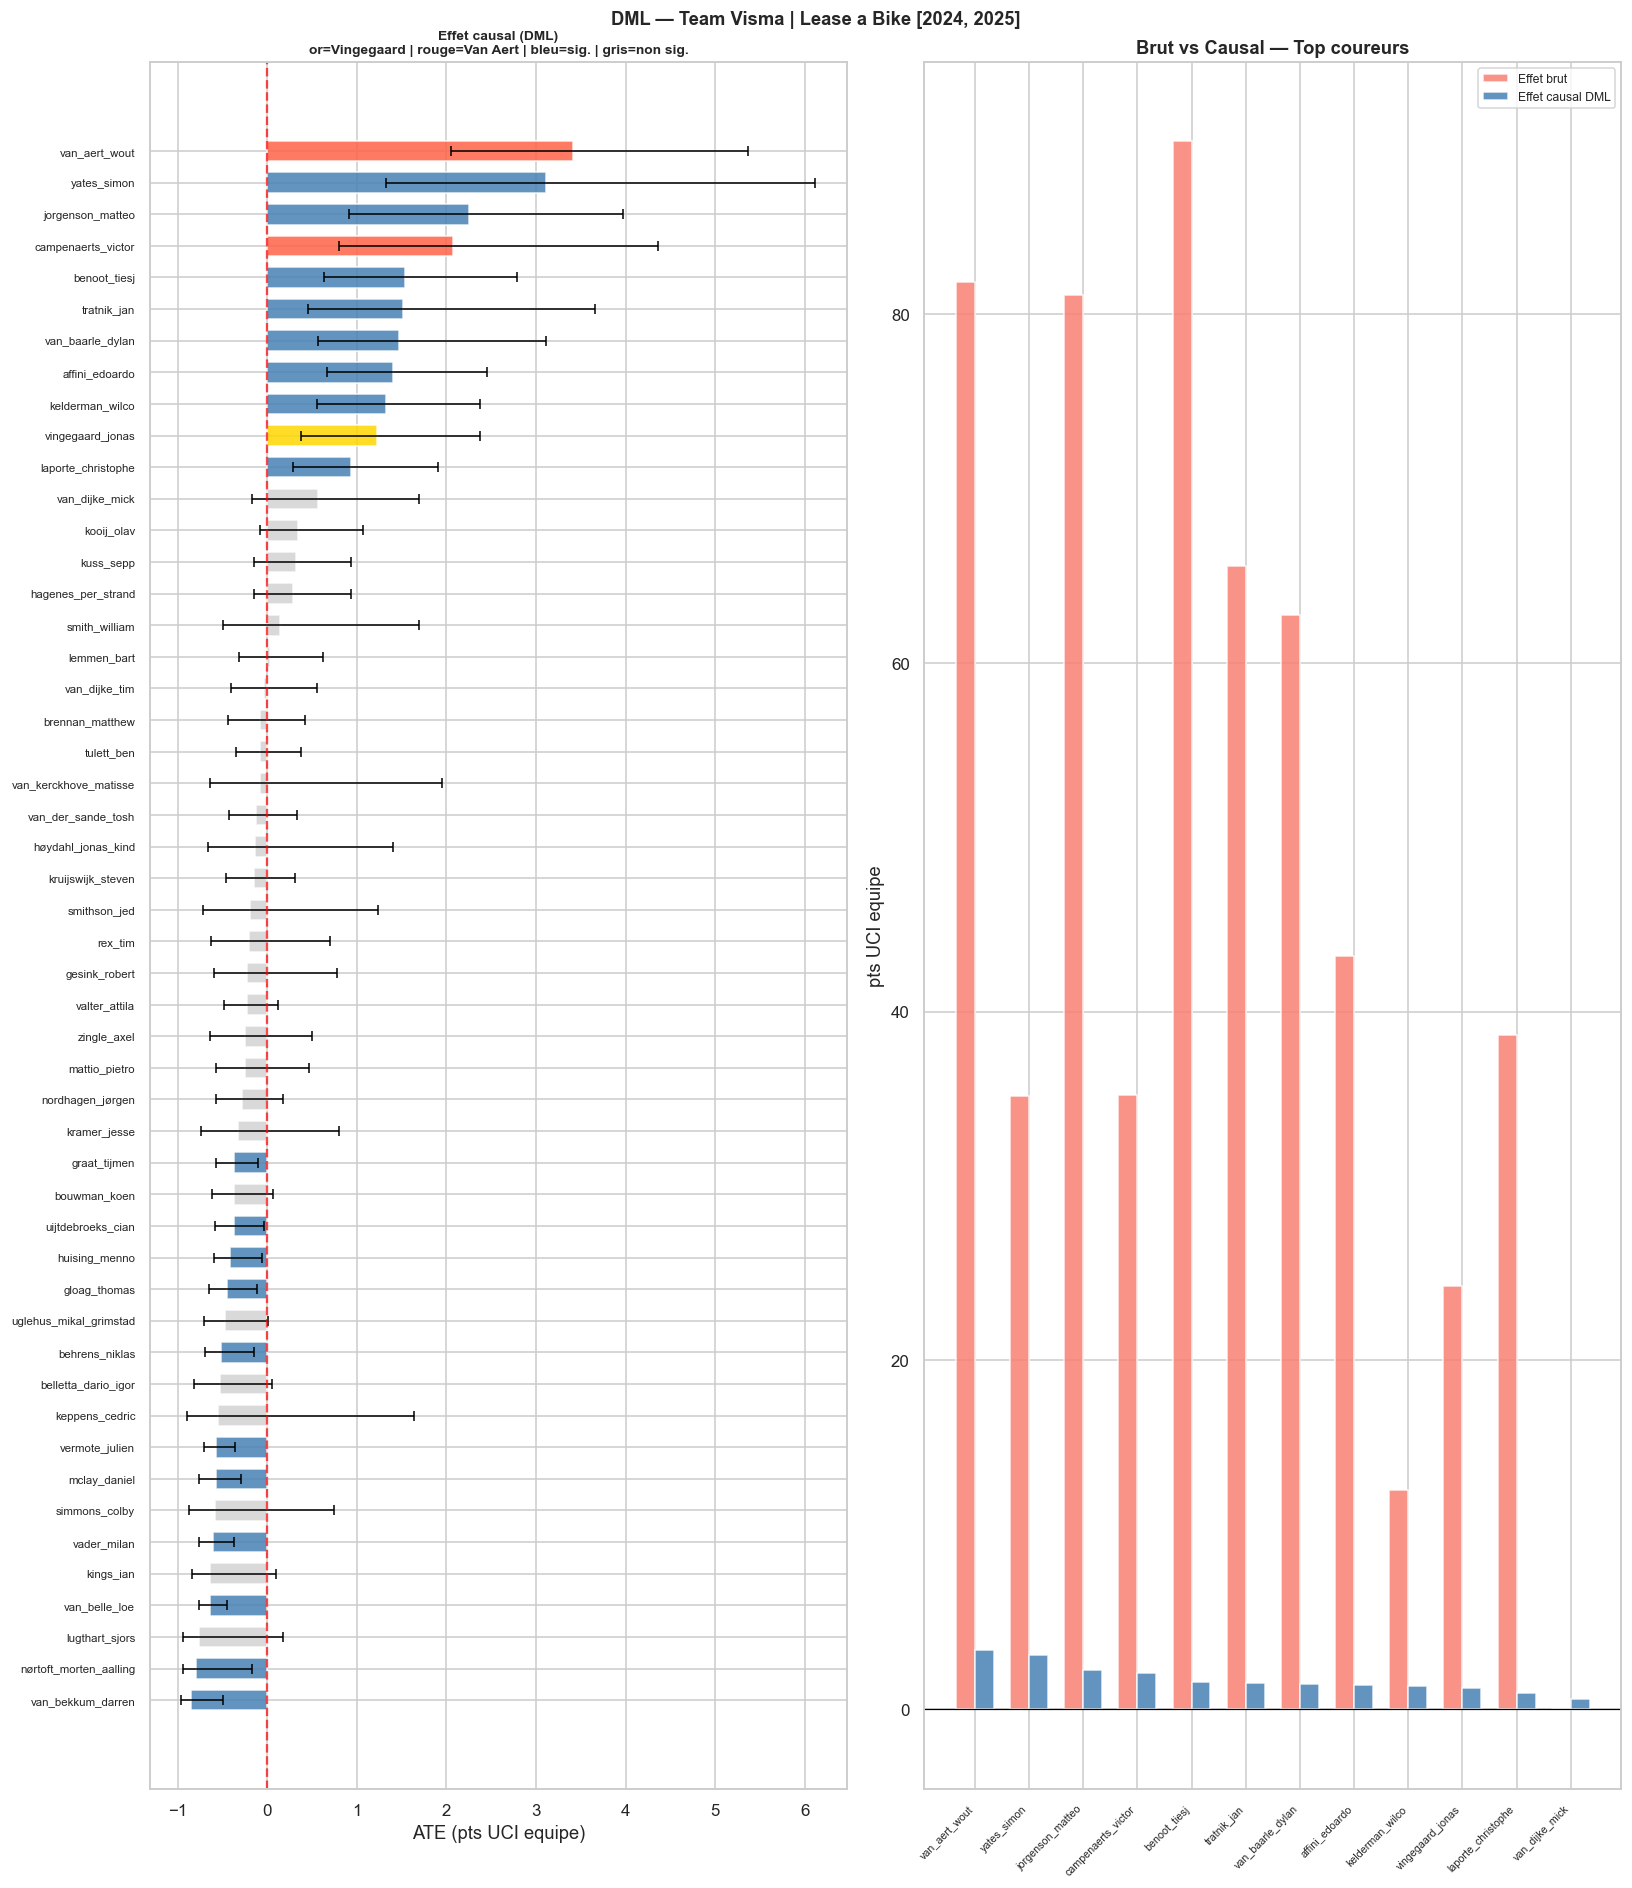

In [12]:
# Forest plot
df_plot = df_results.sort_values('ate_orig', ascending=True)
colors_f = []
for _, row in df_plot.iterrows():
    if 'vingegaard' in row['rider']:
        colors_f.append('gold')
    elif 'aert' in row['rider']:
        colors_f.append('tomato')
    elif row['significant']:
        colors_f.append('steelblue')
    else:
        colors_f.append('lightgray')

fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(df_plot)*0.35)))
y_pos = range(len(df_plot))
axes[0].barh(y_pos, df_plot['ate_orig'], color=colors_f, edgecolor='white', alpha=0.85, height=0.65)
axes[0].errorbar(df_plot['ate_orig'], y_pos,
    xerr=[df_plot['ate_orig']-df_plot['ci_low'], df_plot['ci_high']-df_plot['ate_orig']],
    fmt='none', color='black', capsize=3, linewidth=1)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['rider'], fontsize=7.5)
axes[0].set_xlabel('ATE (pts UCI equipe)')
axes[0].set_title('Effet causal (DML)\nor=Vingegaard | rouge=Van Aert | bleu=sig. | gris=non sig.',
                  fontweight='bold', fontsize=9)

# Effet brut vs causal top coureurs
df_top = df_results.head(min(12, len(df_results)))
x = np.arange(len(df_top))
w = 0.35
axes[1].bar(x-w/2, df_top['effet_brut'], w, label='Effet brut', color='salmon', alpha=0.85)
axes[1].bar(x+w/2, df_top['ate_orig'],   w, label='Effet causal DML', color='steelblue', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_top['rider'], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('pts UCI equipe')
axes[1].set_title('Brut vs Causal — Top coureurs', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle(f'DML — {EQUIPE} {ANNEES}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Causal Forest — Hétérogénéité Vingegaard vs Van Aert

In [13]:
def run_causal_forest(filename, annees, equipe):
    df_r = load_rider(filename, annees, equipe)
    X_r, T_r, Y_r, df_clean_r, features_all = prepare_features(df_r)
    nom = filename.replace('.csv', '')
    print(f'Causal Forest — {nom} ({len(T_r)} obs, {T_r.sum()} selected=1)')
    print('Entrainement...')
    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
        model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),
        n_estimators=500, random_state=42, cv=5
    )
    cf.fit(Y_r, T_r, X=X_r)
    cate = cf.effect(X_r)
    df_clean_r = df_clean_r.copy()
    df_clean_r['cate'] = cate
    print(f'CATE moyen={cate.mean():.3f} | std={cate.std():.3f} | % positifs={((cate>0).mean()*100):.1f}%')
    return cf, cate, df_clean_r, features_all

cf_ving, cate_ving, df_ving_clean, features_all = run_causal_forest(COUREUR_1, ANNEES, EQUIPE)
print()
cf_vda,  cate_vda,  df_vda_clean,  _            = run_causal_forest(COUREUR_2, ANNEES, EQUIPE)

Causal Forest — vingegaard_jonas (469 obs, 102 selected=1)
Entrainement...
CATE moyen=0.669 | std=0.629 | % positifs=84.2%

Causal Forest — van_aert_wout (468 obs, 118 selected=1)
Entrainement...
CATE moyen=1.466 | std=0.248 | % positifs=100.0%


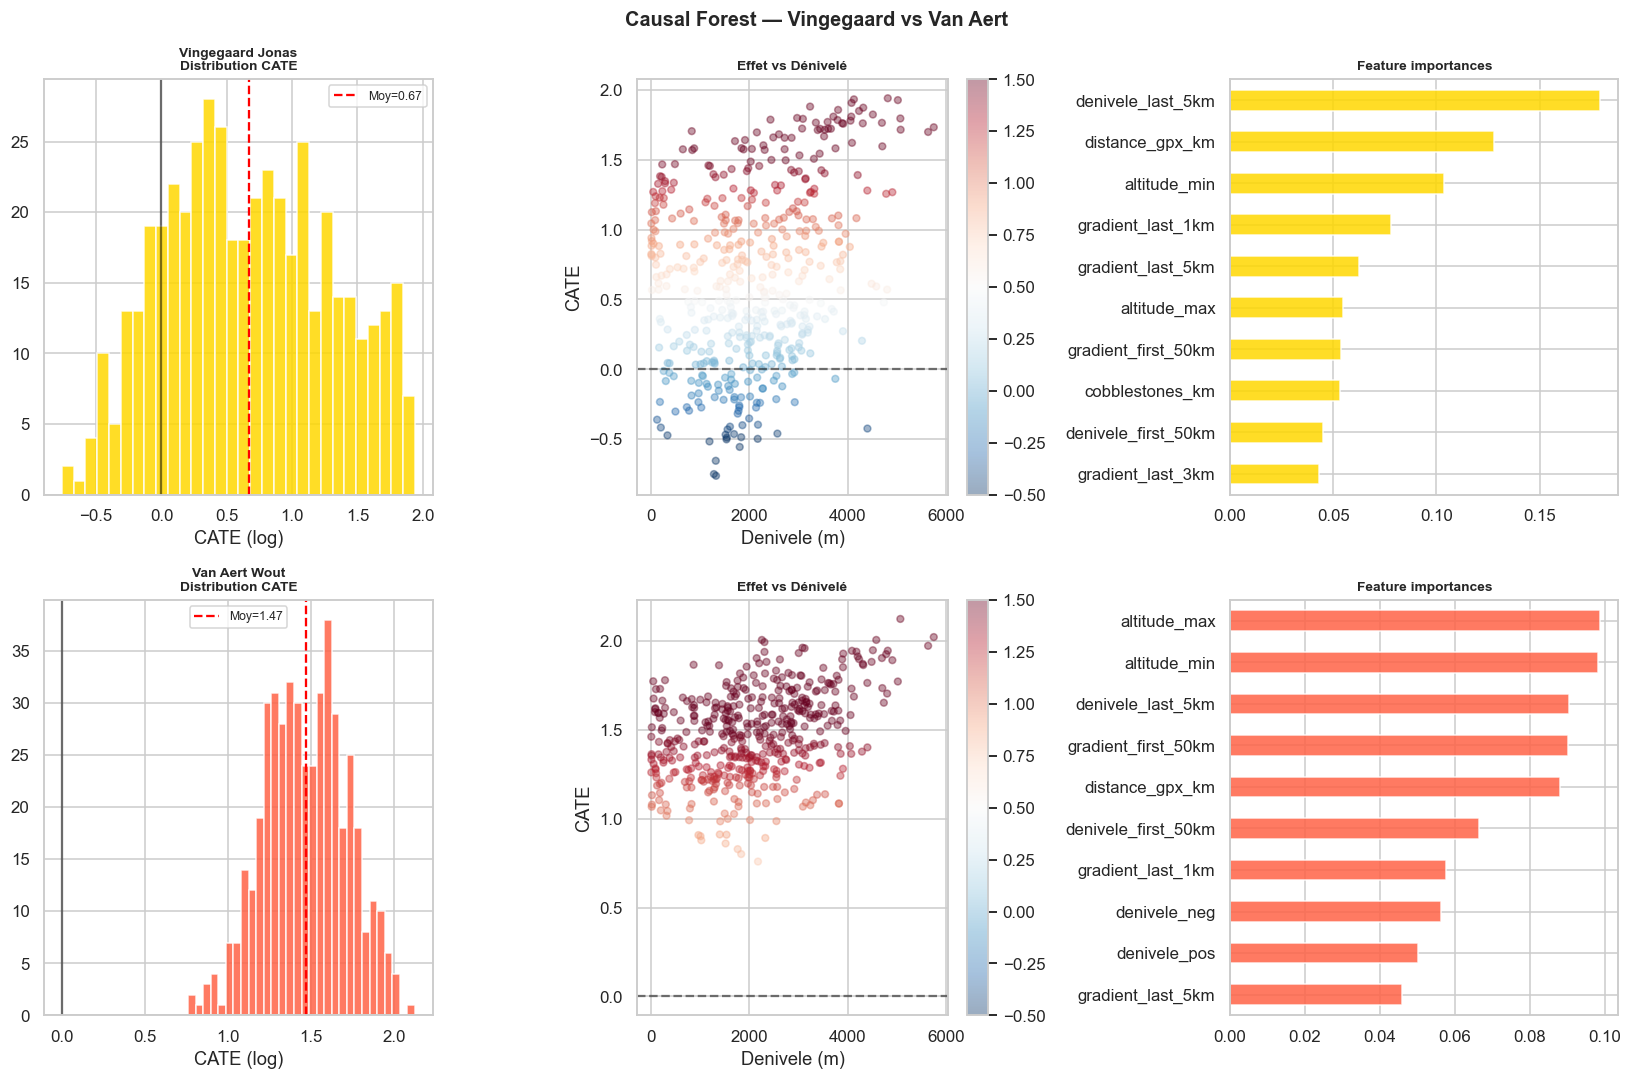

In [14]:
# Visualisation comparative CATE
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (cate, df_c, cf, nom, color) in enumerate([
    (cate_ving, df_ving_clean, cf_ving, 'Vingegaard Jonas', 'gold'),
    (cate_vda,  df_vda_clean,  cf_vda,  'Van Aert Wout',    'tomato')
]):
    # Distribution CATE
    ax = axes[row, 0]
    ax.hist(cate, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(cate.mean(), color='red', linestyle='--', label=f'Moy={cate.mean():.2f}')
    ax.axvline(0, color='black', alpha=0.5)
    ax.set_title(f'{nom}\nDistribution CATE', fontweight='bold', fontsize=9)
    ax.set_xlabel('CATE (log)')
    ax.legend(fontsize=8)

    # CATE vs denivele
    ax = axes[row, 1]
    sc = ax.scatter(df_c['denivele_pos'], cate, c=cate, cmap='RdBu_r',
                    alpha=0.4, s=20, vmin=-0.5, vmax=1.5)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Denivele (m)')
    ax.set_ylabel('CATE')
    ax.set_title('Effet vs Dénivelé', fontweight='bold', fontsize=9)
    plt.colorbar(sc, ax=ax)

    # Feature importances
    ax = axes[row, 2]
    feat_imp = pd.Series(cf.feature_importances_, index=features_all).sort_values(ascending=True).tail(10)
    feat_imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title('Feature importances', fontweight='bold', fontsize=9)

plt.suptitle('Causal Forest — Vingegaard vs Van Aert', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
df_vda_clean_check = df_vda_clean.copy()

# Pts equipe quand present vs absent
print('pts_uci_equipe :')
print(df_vda_clean_check.groupby('selected')['pts_uci_equipe'].describe().round(1))

# Profil des courses present vs absent
cols = ['denivele_pos', 'cobblestones_km', 'distance_gpx_km', 'n_cols_hc']
cols = [c for c in cols if c in df_vda_clean_check.columns]
print('\nProfil des courses :')
print(df_vda_clean_check.groupby('selected')[cols].mean().round(1))

# Distribution des CATE par type de course
df_vda_clean_check['denivele_q'] = pd.qcut(df_vda_clean_check['denivele_pos'], q=4,
    labels=['Q1 Plat', 'Q2', 'Q3', 'Q4 Montagne'])
print('\nCATE moyen par profil :')
print(df_vda_clean_check.groupby('denivele_q')['cate'].mean().round(3))

pts_uci_equipe :
          count   mean    std    min   25%   50%    75%    max
selected                                                      
0        350.00  31.00  65.30 -25.00  0.00  5.00  30.00 530.00
1        118.00 112.90 139.50   0.00 10.00 81.00 155.00 760.00

Profil des courses :
          denivele_pos  cobblestones_km  distance_gpx_km  n_cols_hc
selected                                                           
0              1996.90             1.40           159.10       0.30
1              2337.90             2.50           168.20       0.50

CATE moyen par profil :
denivele_q
Q1 Plat       1.38
Q2            1.40
Q3            1.49
Q4 Montagne   1.60
Name: cate, dtype: float64


In [19]:
row_vda = df_results[df_results['rider'] == nom_vda].iloc[0]
print(f'ATE Van Aert : +{row_vda["ate_orig"]:.2f} pts  IC=[{row_vda["ci_low"]:+.2f}, {row_vda["ci_high"]:+.2f}]  sig={row_vda["significant"]}')
row_ving = df_results[df_results['rider'] == nom_ving].iloc[0]
print(f'ATE Vingegaard : +{row_ving["ate_orig"]:.2f} pts  IC=[{row_ving["ci_low"]:+.2f}, {row_ving["ci_high"]:+.2f}]  sig={row_ving["significant"]}')

ATE Van Aert : +2.07 pts  IC=[+0.80, +4.36]  sig=True
ATE Vingegaard : +1.22 pts  IC=[+0.38, +2.38]  sig=True


## 6. Comparaison des deux profils

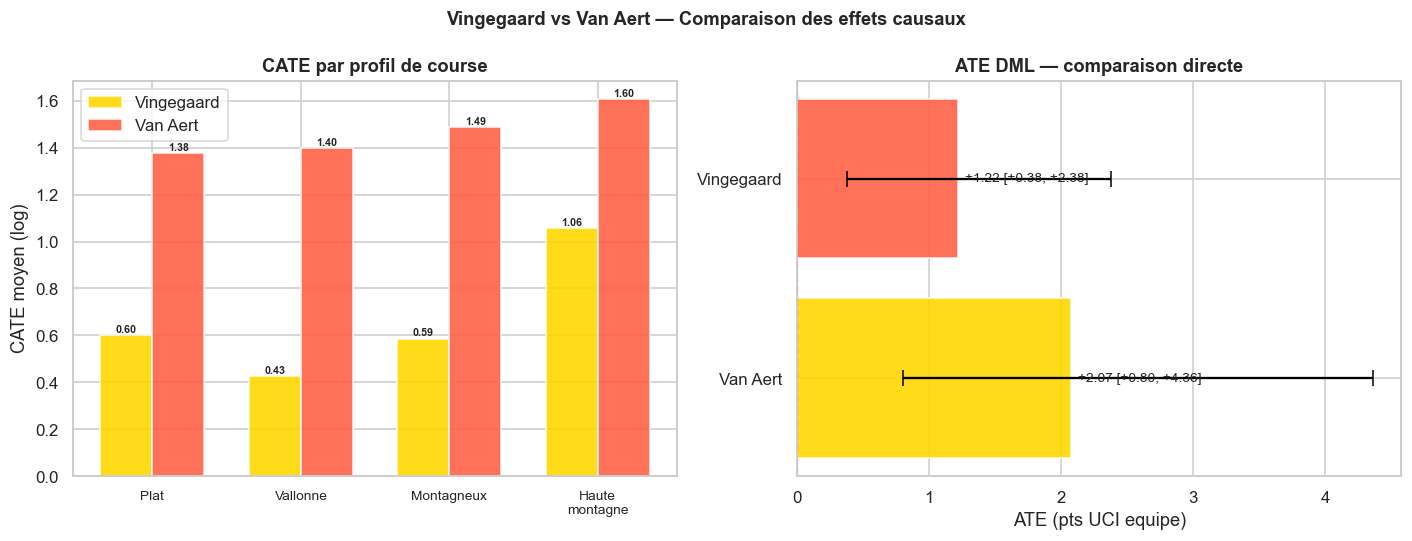

RÉSUMÉ COMPARATIF

Vingegaard :
  ATE DML       : +1.22 pts  IC=[+0.38, +2.38]  sig=True
  Effet brut    : +24.26 pts
  CATE moyen    : 0.669 (log)
  CATE Q1 plat  : 0.601
  CATE Q4 mont. : 1.058

Van Aert :
  ATE DML       : +2.07 pts  IC=[+0.80, +4.36]  sig=True
  Effet brut    : +35.20 pts
  CATE moyen    : 1.466 (log)
  CATE Q1 plat  : 1.378
  CATE Q4 mont. : 1.605


In [15]:
# CATE par quartile de denivele — comparaison
for df_c, cate, nom in [
    (df_ving_clean, cate_ving, 'Vingegaard'),
    (df_vda_clean,  cate_vda,  'Van Aert')
]:
    df_c['denivele_q'] = pd.qcut(df_c['denivele_pos'], q=4,
        labels=['Q1 Plat', 'Q2 Vallonne', 'Q3 Montagneux', 'Q4 Haute montagne'])
    df_c['cate'] = cate

cate_ving_q = df_ving_clean.groupby('denivele_q')['cate'].mean()
cate_vda_q  = df_vda_clean.groupby('denivele_q')['cate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(4)
w = 0.35
axes[0].bar(x-w/2, cate_ving_q.values, w, label='Vingegaard', color='gold',   edgecolor='white', alpha=0.9)
axes[0].bar(x+w/2, cate_vda_q.values,  w, label='Van Aert',   color='tomato', edgecolor='white', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Plat', 'Vallonne', 'Montagneux', 'Haute\nmontagne'], fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('CATE moyen (log)')
axes[0].set_title('CATE par profil de course', fontweight='bold')
axes[0].legend()
for i, (v, va) in enumerate(zip(cate_ving_q.values, cate_vda_q.values)):
    axes[0].text(i-w/2, v+0.01, f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')
    axes[0].text(i+w/2, va+0.01, f'{va:.2f}', ha='center', fontsize=7, fontweight='bold')

# Comparaison ATE DML
df_comp = df_results[df_results['rider'].isin([nom_ving, nom_vda])].copy()
df_comp['label'] = df_comp['rider'].apply(lambda x: 'Vingegaard' if 'vingegaard' in x else 'Van Aert')
colors_comp = ['gold', 'tomato']
axes[1].barh(df_comp['label'], df_comp['ate_orig'], color=colors_comp, edgecolor='white', alpha=0.9)
axes[1].errorbar(df_comp['ate_orig'], df_comp['label'],
    xerr=[df_comp['ate_orig']-df_comp['ci_low'], df_comp['ci_high']-df_comp['ate_orig']],
    fmt='none', color='black', capsize=5, linewidth=1.5)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].set_xlabel('ATE (pts UCI equipe)')
axes[1].set_title('ATE DML — comparaison directe', fontweight='bold')
for _, row in df_comp.iterrows():
    axes[1].text(row['ate_orig']+0.05, row['label'],
                 f"+{row['ate_orig']:.2f} [{row['ci_low']:+.2f}, {row['ci_high']:+.2f}]",
                 va='center', fontsize=9)

plt.suptitle('Vingegaard vs Van Aert — Comparaison des effets causaux', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé textuel
print('=' * 55)
print('RÉSUMÉ COMPARATIF')
print('=' * 55)
for df_c, cate, nom, f in [
    (df_ving_clean, cate_ving, 'Vingegaard', nom_ving),
    (df_vda_clean,  cate_vda,  'Van Aert',   nom_vda)
]:
    row = df_results[df_results['rider'] == f].iloc[0]
    print(f'\n{nom} :')
    print(f'  ATE DML       : +{row["ate_orig"]:.2f} pts  IC=[{row["ci_low"]:+.2f}, {row["ci_high"]:+.2f}]  sig={row["significant"]}')
    print(f'  Effet brut    : +{row["effet_brut"]:.2f} pts')
    print(f'  CATE moyen    : {cate.mean():.3f} (log)')
    print(f'  CATE Q1 plat  : {df_c.groupby("denivele_q")["cate"].mean()["Q1 Plat"]:.3f}')
    print(f'  CATE Q4 mont. : {df_c.groupby("denivele_q")["cate"].mean()["Q4 Haute montagne"]:.3f}')
print('=' * 55)